# Exploring entrepreneurship in France (2012–2024)

Entrepreneurship in France has undergone a fundamental transformation over the past decade. The public narrative often highlights a 'youth boom', particularly the claim that **40% of new entrepreneurs are under 30 years old**.

This project aims to explore **business creation trends in France** using **INSEE’s public data** on new businesses between 2012 and 2024.  
The goal is to understand:
- How have business creations evolved in France over the last 12 years?
- How do trends differ by gender, age group, legal form, and sector of activity?
- Which demographic or structural segments are contributing most to entrepreneurship growth?
- Are recent policy changes or economic events visible in the data?

Through this exploratory analysis, we’ll visualize and interpret how entrepreneurship in France has transformed over the last decade.


# Installation and imports

In [1]:
!pip install --upgrade pip
!pip install pandas numpy matplotlib seaborn plotly 

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Imports des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="muted")


# Data source 
This analysis uses data from **INSEE (Institut National de la Statistique et des Études Économiques)** on **business creations in France**.  
Data available via https://www.data.gouv.fr/datasets/creations-dentreprises-individuelles-unites-legales/

In [3]:
# Load INSEE data (please make sure both CSVs are in the 'data' folder)

import zipfile
with zipfile.ZipFile("data.zip") as z:
    with z.open("DS_SIDE_CREA_EI_2024_data.csv") as f1, z.open("DS_SIDE_CREA_EI_2024_metadata.csv") as f2:
        data = pd.read_csv(f1, sep=";", encoding="utf-8")
        meta = pd.read_csv(f2, sep=";", encoding="utf-8")

print("✅ Data loaded successfully")
print(f"Data shape: {data.shape}")
print(f"Metadata shape: {meta.shape}")

✅ Data loaded successfully
Data shape: (561600, 10)
Metadata shape: (162, 4)


# Understanding the data set

The dataset provides a multidimensional view of entrepreneurship by sector, region, age, gender, and legal form, between 2012 and 2024.
 
**Numeric Variables :**
| Variable      | Description                                                                                       |
|---------------|---------------------------------------------------------------------------------------------------|
| OBS_VALUE     | Number of new *entreprises individuelles* (individual businesses) registered during a given year. |
| TIME_PERIOD   | Year (2012–2024).                                                              |

**Categrical Variables :**
| Variable     | Description                                                                                                  |
|--------------|--------------------------------------------------------------------------------------------------------------|
| ACTIVITY     | Sector of activity (NAF/APE classification INSEE).                                                                  |
| AGE          | Age group of the business creator.                                                                            |
| SEX          | Gender of the business creator.                                                                               |
| LEGAL_FORM   | Legal form of the enterprise: `MICRO` (micro-entrepreneur), `ENTIND_X_MICRO` (individual business excl. micro), `_T` (total). |
| GEO          | Geographic code: `FRANCE` (national), `REG` (regions), `DEP` (departments, e.g., 75 = Paris).                |
| GEO_OBJECT   | Geographic level: France, region, or department.                                                              |
| SIDE_MEASURE | Type of measure (always `BURE` = number of newly created legal units).                                        |
| FREQ         | Frequency of observation (always `A` = annual).                                                               |


The data includes a metadata dictionary (`_metadata.csv`).

In [4]:
data.head()

,ACTIVITY,AGE,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SEX,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE
0,N,_T,A,F,FRANCE,_T,F,BURE,2024,39587
1,S,_T,A,F,FRANCE,_T,_T,BURE,2023,74413
2,Q,_T,A,F,FRANCE,ENTIND_X_MICRO,_T,BURE,2024,28804
3,G,_T,A,F,FRANCE,_T,M,BURE,2019,57364
4,S,_T,A,F,FRANCE,_T,_T,BURE,2019,46516


In [5]:
data_columns = list(data.columns)
for col in data_columns:
    print(f"{col} :", data[col].unique())

ACTIVITY : ['N' 'S' 'Q' 'G' 'BTSXO' 'F' 'L' 'R' 'BE' 'I' 'J' 'P' 'K' 'H' 'M']
AGE : ['_T' 'Y50T59' 'Y_LT30' 'Y30T39' 'Y_GE60' 'Y40T49']
FREQ : ['A']
GEO : ['F' '10' '44' '74' '972' '29' '77' '23' '33' '45' '82' '86' '11' '66'
 '05' '03' '69' '87' '24' '67' '974' '31' '85' '83' '32' '52' '37' '84'
 '93' '02' '60' '57' '61' '65' '54' '88' '06' '27' '07' '63' '58' '64'
 '36' '973' '49' '15' '09' '80' '12' '89' '42' '08' '78' '43' '17' '30'
 '59' '22' '72' '01' '14' '41' '56' '94' '75' '971' '25' '28' '40' '90'
 '46' '76' '79' '51' '70' '21' '2B' '2A' '81' '34' '976' '50' '71' '91'
 '39' '04' '73' '62' '13' '16' '92' '19' '47' '35' '48' '55' '53' '95'
 '18' '26' '68' '38']
GEO_OBJECT : ['FRANCE' 'DEP' 'REG']
LEGAL_FORM : ['_T' 'ENTIND_X_MICRO' 'MICRO']
SEX : ['F' '_T' 'M']
SIDE_MEASURE : ['BURE']
TIME_PERIOD : [2024 2023 2019 2014 2015 2013 2017 2012 2022 2016 2018 2020 2021]
OBS_VALUE : [39587 74413 28804 ... 71328  4465     0]


In [6]:
data.info() 
data.shape

print("\nNumber of rows:", len(data))
print("\nNumber of columns:", len(data.columns))
print("\nTime coverage:", data["TIME_PERIOD"].min(), "to", data["TIME_PERIOD"].max())
print("\nGeographic levels:")
print(data["GEO_OBJECT"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561600 entries, 0 to 561599
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ACTIVITY      561600 non-null  object
 1   AGE           561600 non-null  object
 2   FREQ          561600 non-null  object
 3   GEO           561600 non-null  object
 4   GEO_OBJECT    561600 non-null  object
 5   LEGAL_FORM    561600 non-null  object
 6   SEX           561600 non-null  object
 7   SIDE_MEASURE  561600 non-null  object
 8   TIME_PERIOD   561600 non-null  int64 
 9   OBS_VALUE     561600 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 42.8+ MB

Number of rows: 561600

Number of columns: 10

Time coverage: 2012 to 2024

Geographic levels:
GEO_OBJECT
DEP       472680
REG        84240
FRANCE      4680
Name: count, dtype: int64


## Missing values and duplicates

In [7]:
print("\nMissing values per column:")
print(data.isna().sum())

dup_keys = ["TIME_PERIOD","GEO","GEO_OBJECT","ACTIVITY","SEX","AGE","LEGAL_FORM","SIDE_MEASURE","FREQ"]
print("\nDuplicate rows (same keys):", data.duplicated(dup_keys).sum())


Missing values per column:
ACTIVITY        0
AGE             0
FREQ            0
GEO             0
GEO_OBJECT      0
LEGAL_FORM      0
SEX             0
SIDE_MEASURE    0
TIME_PERIOD     0
OBS_VALUE       0
dtype: int64

Duplicate rows (same keys): 0


## Descriptive statistics

In [8]:
print("\nNumerical summary:")
print(data.describe())

print("\nOBS_VALUE by geographic level:")
print(data.groupby("GEO_OBJECT")["OBS_VALUE"].describe())


Numerical summary:
         TIME_PERIOD      OBS_VALUE
count  561600.000000  561600.000000
mean     2018.000000     319.051282
std         3.741661    5607.190489
min      2012.000000       0.000000
25%      2015.000000       0.000000
50%      2018.000000       0.000000
75%      2021.000000       0.000000
max      2024.000000  826674.000000

OBS_VALUE by geographic level:
               count          mean           std   min     25%     50%  \
GEO_OBJECT                                                               
DEP         472680.0     94.767708    815.019266   0.0     0.0     0.0   
FRANCE        4680.0  19143.076923  54504.721111  17.0  1342.5  4921.0   
REG          84240.0    531.752137   4566.845820   0.0     0.0     0.0   

                75%       max  
GEO_OBJECT                     
DEP             0.0   59716.0  
FRANCE      14629.5  826674.0  
REG             0.0  215951.0  


## Meta data
Let's use metadata to add readable labels

In [9]:
meta.head()

,COD_VAR,LIB_VAR,COD_MOD,LIB_MOD
0,ACTIVITY,Activité économique,BE,"Industrie manufacturière, industries extractiv..."
1,ACTIVITY,Activité économique,F,Construction
2,ACTIVITY,Activité économique,G,Commerce ; réparation d'automobiles et de moto...
3,ACTIVITY,Activité économique,H,Transports et entreposage
4,ACTIVITY,Activité économique,I,Hébergement et restauration


In [10]:
# Create mapping dictionaries from metadata
# For each group COD_VAR, we take the columns COD_MOD and LIB_MOD and zip them together to make a dictionary.
label_dicts = (
    meta.groupby("COD_VAR", group_keys=False)
    .apply(lambda x: dict(zip(x["COD_MOD"], x["LIB_MOD"])), include_groups=False)
    .to_dict()
)

In [11]:
# Apply the mappings to the data
for var, mapping in label_dicts.items():
    if var in data.columns:
        data[var + "_LABEL"] = data[var].map(mapping)

data.head()

,ACTIVITY,AGE,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SEX,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE,ACTIVITY_LABEL,AGE_LABEL,FREQ_LABEL,GEO_LABEL,LEGAL_FORM_LABEL,SEX_LABEL,SIDE_MEASURE_LABEL,TIME_PERIOD_LABEL
0,N,_T,A,F,FRANCE,_T,F,BURE,2024,39587,Activités de services administratifs et de sou...,Total,Annuel,France,Total,Femme,Nombre de nouvelles unités légales enregistrées,NaN
1,S,_T,A,F,FRANCE,_T,_T,BURE,2023,74413,Autres activités de services,Total,Annuel,France,Total,Total,Nombre de nouvelles unités légales enregistrées,NaN
2,Q,_T,A,F,FRANCE,ENTIND_X_MICRO,_T,BURE,2024,28804,Santé humaine et action sociale,Total,Annuel,France,Entreprises individuelles hors micro-entrepren...,Total,Nombre de nouvelles unités légales enregistrées,NaN
3,G,_T,A,F,FRANCE,_T,M,BURE,2019,57364,Commerce ; réparation d'automobiles et de moto...,Total,Annuel,France,Total,Homme,Nombre de nouvelles unités légales enregistrées,NaN
4,S,_T,A,F,FRANCE,_T,_T,BURE,2019,46516,Autres activités de services,Total,Annuel,France,Total,Total,Nombre de nouvelles unités légales enregistrées,NaN


In [12]:
# Keep a clean version of the data
data.to_csv("clean_data.csv", index=False)


In [13]:
# Keep a clean version for power BI use

sex_data = data[
    (data["SEX"] != "_T") &
    (data["AGE"] == "_T") &
    (data["LEGAL_FORM"] == "_T") &
    (data["ACTIVITY"] == "_T")
]
sex_data.to_csv("data/sex_data_powerbi.csv", index=False)

sex_data = data[
    (data["SEX"] != "_T") &
    (data["AGE"] == "_T") &
    (data["LEGAL_FORM"] == "_T") &
    (data["ACTIVITY"] == "_T")
]
sex_data.to_csv("data/sex_data_powerbi.csv", index=False)

# Exploratory Data Analysis

### [Overview of main trends](#overview)  
- [Evolution of business creations over time](#evolution-of-business-creations-over-time)
- [Top regions by number of creations (latest year)](#region-over-time)
- [Sectoral distribution](#sector)

### [Demographic insights](#demographic)  
- [Gender distribution (national level)](#gender)  
- [Age distribution](#age)  

### [Legal form](#legal)  
- [Legal form distribution over time](#legal_dist)  

## Overview of main trends <a id="overview"></a>

### Evolution of business creations over time <a id="evolution-of-business-creations-over-time"></a>


In [14]:
# Focus on cleaned data
data = data.copy()

filter_france = data["GEO_OBJECT"] == "FRANCE"
age_total = data["AGE"] == "_T"
sex_total = data["SEX"] == "_T"
legal_form_total = data["LEGAL_FORM"] == "_T"





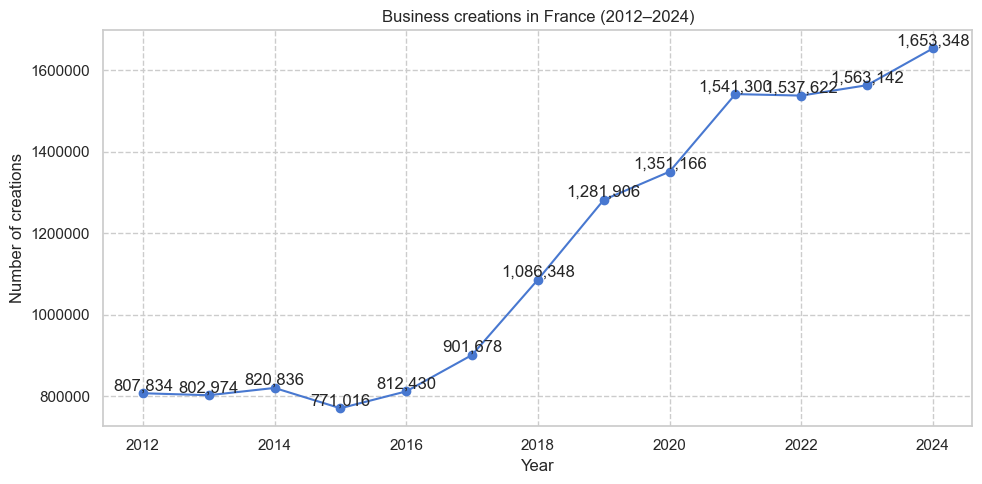

In [15]:
fr = data[
    filter_france
    & age_total
    & sex_total
    & legal_form_total
]

# Group by year and sum all values
trend = fr.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum()

# Simple line plot
plt.figure(figsize=(10,5))
plt.plot(trend["TIME_PERIOD"], trend["OBS_VALUE"], marker="o")

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x)}"))

# Add data labels
for x, y in zip(trend["TIME_PERIOD"], trend["OBS_VALUE"]):
    plt.text(x, y, f"{y:,}", ha="center", va="bottom")

# Titles and labels
plt.title("Business creations in France (2012–2024)")
plt.xlabel("Year")
plt.ylabel("Number of creations")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


#### Insights 
- Business creation nearly doubled over the period, rising from around 800k in 2012 to more than 1.6M in 2024.
- From 2012 to 2016, volumes remained relatively stable, with only minor yearly fluctuations.
- The turning point occurs in 2017, where growth becomes consistently stronger. This aligns with regulatory updates that simplified the micro-entrepreneur status.
- Although the COVID-19 pandemic in 2020 might have constrained economic activity, business creation remained resilient and continued to grow in subsequent years.  

The long-term increase indicates a shift toward simplified legal structures and small-scale independent activities rather than broad expansion across all business types.


### Top regions by number of creations (latest year) <a id="region-over-time"></a>

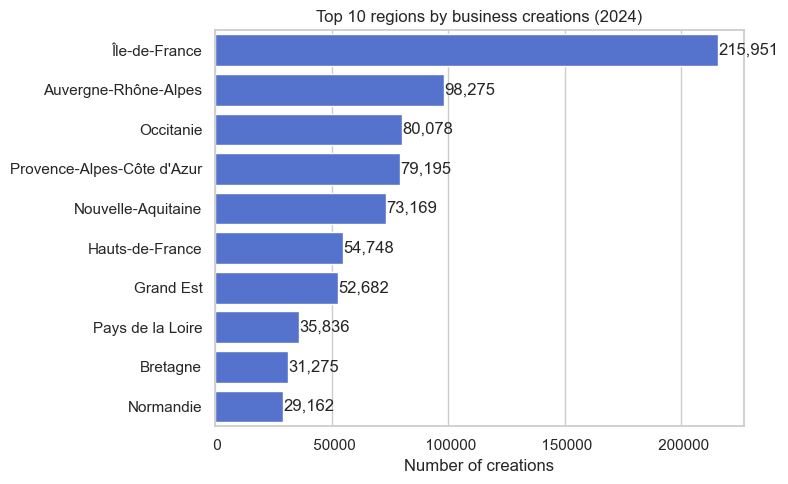

In [16]:
import matplotlib.ticker as ticker 

latest_year = data["TIME_PERIOD"].max()

region_data = data[
    (data["GEO_OBJECT"] == "REG")
    & age_total
    & sex_total
    & legal_form_total
    & (data["TIME_PERIOD"] == latest_year)
]

top_regions = (
    region_data.groupby("GEO_LABEL", as_index=False)["OBS_VALUE"].sum()
    .sort_values("OBS_VALUE", ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=top_regions, y="GEO_LABEL", x="OBS_VALUE", color="royalblue")

# Add labels on bars
for i, v in enumerate(top_regions["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center')

# Fix x-axis formatting (no scientific notation)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))

plt.title(f"Top 10 regions by business creations ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.tight_layout()
plt.show()


#### Insights 
- Île-de-France dominates with more than 215k business creations, over twice the volume of the second region.
- Regions such as **Auvergne-Rhône-Alpes**, **Occitanie**, and **Provence-Alpes-Côte d’Azur** also show high levels of entrepreneurship.
- By contrast, regions with smaller populations, like **Bretagne** or **Normandie**, record lower absolute numbers.

The ranking largely mirrors population size and economic weight. It suggests that regional differences in business creation align with broader structural factors (e.g., urban density, employment markets).

### Sectoral distribution <a id="sector"></a>

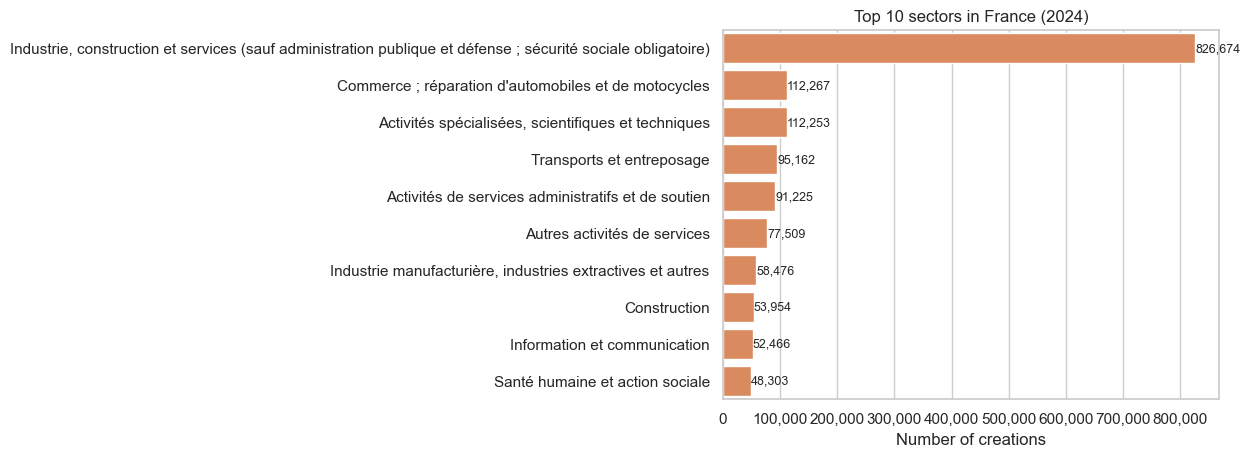

In [17]:
sector_data = data[
    filter_france
    & age_total
    & sex_total
    & legal_form_total
    & (data["TIME_PERIOD"] == latest_year)
]

top_sectors = (sector_data.groupby("ACTIVITY_LABEL", as_index=False)["OBS_VALUE"].sum()
               .sort_values("OBS_VALUE", ascending=False)
              .head(10))

ax = sns.barplot(data=top_sectors, y="ACTIVITY_LABEL", x="OBS_VALUE")

# Add labels on bars
for i, v in enumerate(top_sectors["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center', fontsize=9)

# Fix x-axis formatting (no scientific notation)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

sns.barplot(data=top_sectors.head(10), x="OBS_VALUE", y="ACTIVITY_LABEL")
plt.title(f"Top 10 sectors in France ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()


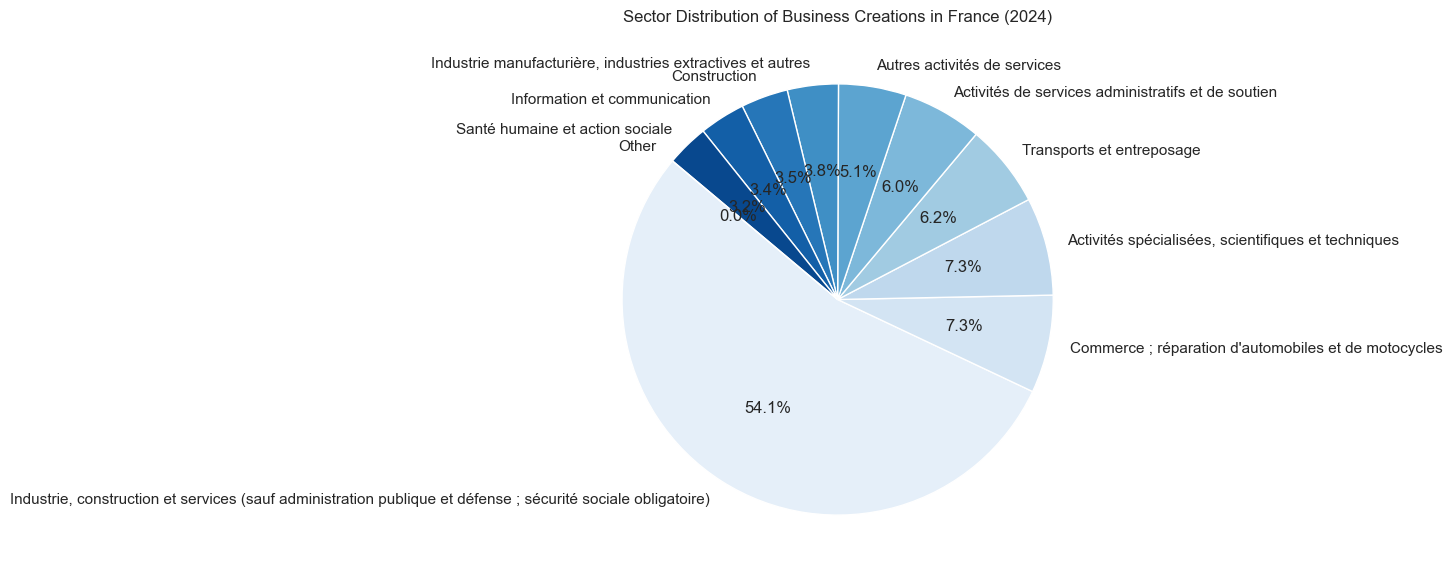

In [18]:
# Pie chart of sector distribution (latest year)
plt.figure(figsize=(7,7))

others_sum = top_sectors["OBS_VALUE"].iloc[10:].sum()

# Append "Other" category
top10_other = pd.concat([top_sectors, pd.DataFrame({"ACTIVITY_LABEL": ["Other"], "OBS_VALUE": [others_sum]})])

plt.pie(
    top10_other["OBS_VALUE"],
    labels=top10_other["ACTIVITY_LABEL"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Blues", n_colors=10)
)

plt.title(f"Sector Distribution of Business Creations in France ({latest_year})")

plt.show()


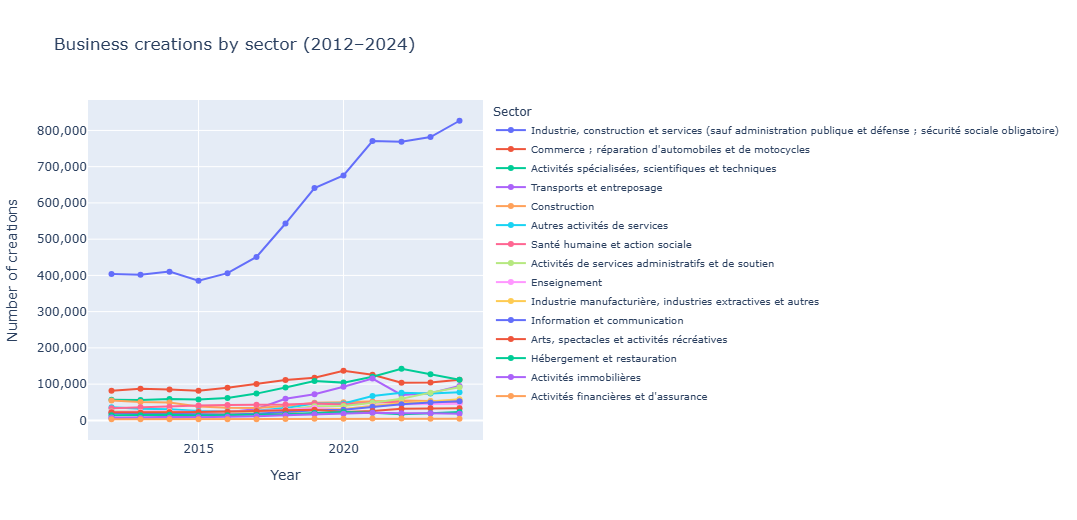

In [19]:
sector_data_trend = data[
    filter_france
    & age_total
    & sex_total
    & legal_form_total
]

sector_trend = (sector_data_trend.groupby(["TIME_PERIOD", "ACTIVITY_LABEL"], as_index=False)["OBS_VALUE"].sum())

# order for the legend
order = (
    sector_trend.groupby("ACTIVITY_LABEL")["OBS_VALUE"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# plot line graph
fig = px.line(
    sector_trend,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    color="ACTIVITY_LABEL",
    markers=True,
    title="Business creations by sector (2012–2024)", 
    category_orders={"ACTIVITY_LABEL": list(order)}
)

fig.update_yaxes(tickformat=",")

fig.update_layout(
    width=1200,
    height=500,
    xaxis_title="Year",
    yaxis_title="Number of creations",
    legend=dict(
        title="Sector",
        font=dict(size=10),
        x=1.02, y=1
    )
)

fig.show()




#### Insights
Overall, the rise in business creation is really carried by a few large service-oriented sectors, while the rest of the economy changes much more slowly.
- The sector “Industrie, construction et services (hors administration)” stands out clearly. It grows from about 400k creations to more than 800k, and it’s the main driver behind the national increase.
- "Commerce & réparation automobile" and "activités spécialisées, scientifiques et techniques" follow far behind but still show steady growth over the period.
- "Transports et entreposage" shows steady growth up to 2021. This trend likely reflects the broader expansion of home delivery, logistics services, and independent courier activity.


> The concentration of new businesses in commerce, administrative services, and construction may suggest that sectors requiring low initial investment or specific expertise attract more entrepreneurs.  
> The relatively smaller share of industrial and digital sectors could indicate higher entry barriers or slower adaptation to independent work models.
> It may also reflect how the micro-entrepreneur regime primarily supports service-oriented and flexible activities.

## Demographic insight <a id="demographic"></a>

### Gender distribution (national level) <a id="gender"></a>

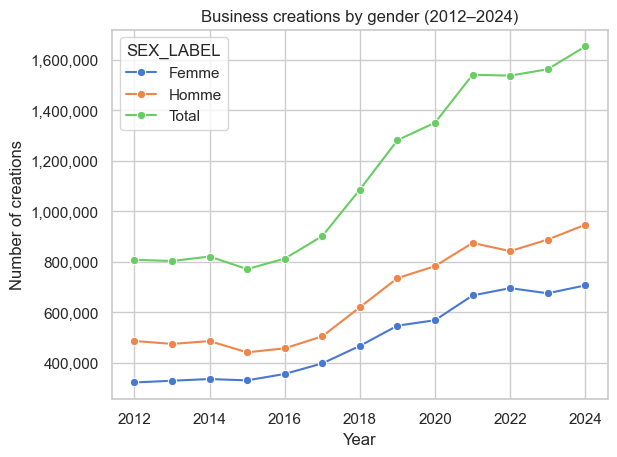

In [20]:
gender = data[
    filter_france
    & age_total
    & legal_form_total
]

gender_trend = (gender.groupby(["TIME_PERIOD", "SEX_LABEL"], as_index=False)["OBS_VALUE"].sum())

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

sns.lineplot(data=gender_trend, x="TIME_PERIOD", y="OBS_VALUE", hue="SEX_LABEL", marker="o")
plt.title("Business creations by gender (2012–2024)")
plt.xlabel("Year")
plt.ylabel("Number of creations")
plt.show()


In [21]:

# Pivot to have one column per gender
gender_df = gender_trend.pivot(index="TIME_PERIOD", columns="SEX_LABEL", values="OBS_VALUE").fillna(0)

# Calculate total and percentage
gender_df["% Femme"] = (gender_df["Femme"] / gender_df["Total"] * 100).round(1)
gender_df["% Homme"] = (gender_df["Homme"] / gender_df["Total"] * 100).round(1)

# Display simple DataFrame
gender_df[["Femme", "Homme", "Total", "% Femme", "% Homme"]]


SEX_LABEL,Femme,Homme,Total,% Femme,% Homme
TIME_PERIOD,,,,,
2012,321730,486104,807834,39.8,60.2
2013,328504,474470,802974,40.9,59.1
2014,335236,485600,820836,40.8,59.2
2015,329986,441030,771016,42.8,57.2
2016,355438,456992,812430,43.7,56.3
2017,397250,504428,901678,44.1,55.9
2018,466530,619818,1086348,42.9,57.1
2019,546804,735102,1281906,42.7,57.3
2020,568308,782858,1351166,42.1,57.9


#### Insights 

- The total number of new businesses grows from about 790,000 in 2012 to more than 1.6 million in 2024.
- During this period, the number of men creating businesses increases from roughly 475,000 to 925,000, and the number of women increases from about 315,000 to 690,000.
- Even with this growth, the gender gap remains stable: men represent around 57–58% of new entrepreneurs, while women stay around 42–43% every year.


### Age distribution <a id="age"></a>

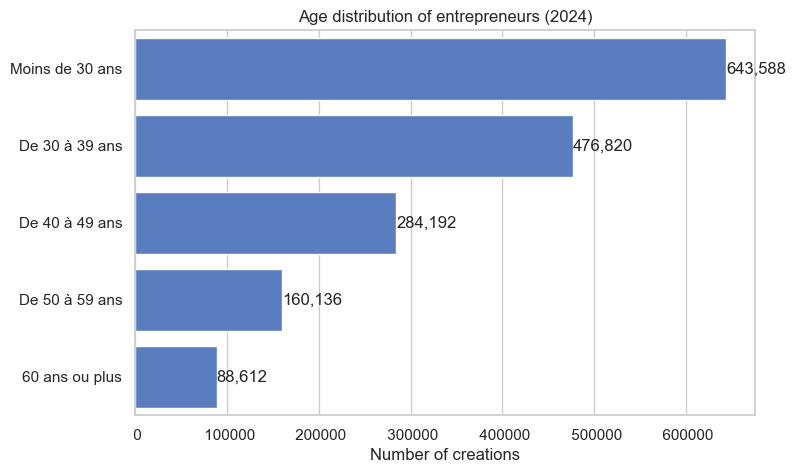

In [22]:
age_data_last_year = data[
    filter_france 
    & sex_total
    & legal_form_total
    & (data["TIME_PERIOD"] == latest_year) 
    & (data["AGE_LABEL"] != "Total")]

age_dist = (age_data_last_year.groupby("AGE_LABEL", as_index=False)["OBS_VALUE"].sum()
            .sort_values("OBS_VALUE", ascending=False))


plt.figure(figsize=(8,5))
ax = sns.barplot(data=age_dist, x="OBS_VALUE", y="AGE_LABEL")

for i, v in enumerate(age_dist["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center')

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))
plt.title(f"Age distribution of entrepreneurs ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()



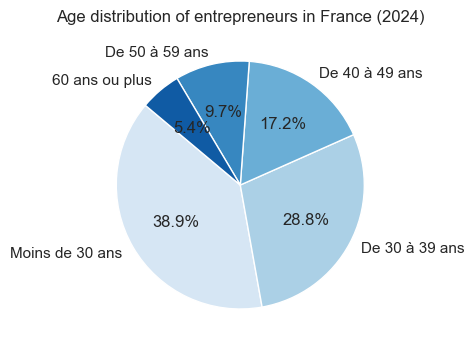

In [23]:
plt.figure(figsize=(4,7))
plt.pie(
    age_dist["OBS_VALUE"],
    labels=age_dist["AGE_LABEL"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Blues", n_colors=len(age_dist))
)

plt.title(f"Age distribution of entrepreneurs in France ({latest_year})")
plt.show()

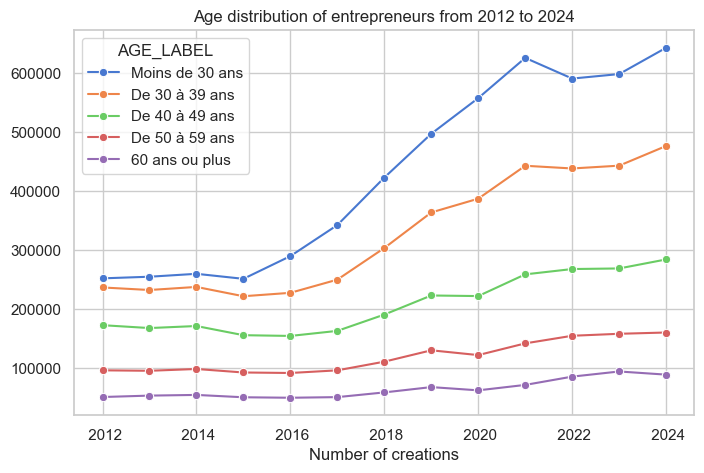

In [24]:
age_data = data[
    filter_france 
    & sex_total
    & legal_form_total 
    & (data["AGE_LABEL"] != "Total")]

age_dist = (age_data.groupby(["TIME_PERIOD", "AGE_LABEL"], as_index=False)["OBS_VALUE"].sum()
            .sort_values("OBS_VALUE", ascending=False))


plt.figure(figsize=(8,5))
ax = sns.lineplot(data=age_dist, x="TIME_PERIOD", y="OBS_VALUE", hue="AGE_LABEL", marker="o")



ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))
plt.title(f"Age distribution of entrepreneurs from 2012 to 2024")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()

#### Insights

Entrepreneurship in France appears to be driven primarily by younger age groups, with individuals under 30 representing nearly 40% of new business creations in 2024. Those aged between 30–39 also make up a significant portion.

This pattern may indicate that younger generations are increasingly attracted to entrepreneurship, possibly due to:
- the flexibility offered by the micro-entrepreneur regime,
- the rise of digital platforms which facilitates self-employment,
- a cultural shift toward autonomy and alternative career paths.

This may suggest that entrepreneurship is becoming an earlier career choice, contrasting with older generations who tend to enter entrepreneurship later or less frequently.

## Legal form <a id="legal"></a>

### Legal form distribution over time <a id="legal_dist"></a>

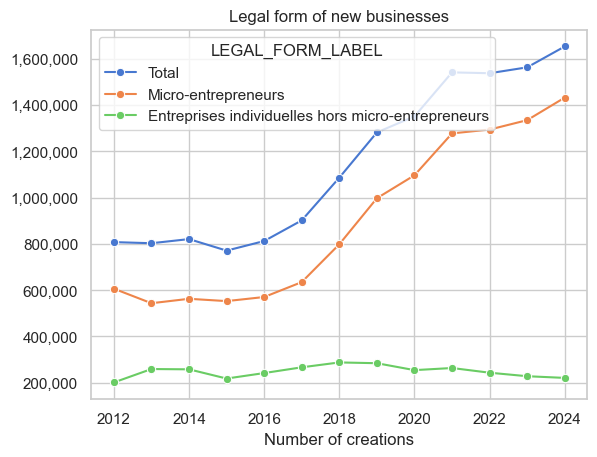

In [25]:
legal_data = data[
    filter_france 
    & age_total
    & sex_total]

legal_dist = (legal_data.groupby(["TIME_PERIOD", "LEGAL_FORM_LABEL"], as_index=False)["OBS_VALUE"].sum()
              .sort_values("OBS_VALUE", ascending=False))

sns.lineplot(data=legal_dist, x="TIME_PERIOD", y="OBS_VALUE", hue="LEGAL_FORM_LABEL", marker ='o')

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title(f"Legal form of new businesses")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()



#### Insights 
- Micro-entrepreneurs drive almost all of the growth in new business creation. Their numbers rise from about 600,000 in 2012 to more than 1.4 million in 2024, with a sharp acceleration after 2017.

- Traditional individual enterprises (hors micro-entrepreneurs) stay relatively stable throughout the period. They fluctuate between 200,000 and 300,000 creations per year, showing no major long-term increase.

- The Total curve closely follows the micro-entrepreneur trend, confirming that the rise in overall entrepreneurship is mainly due to the expansion of the micro-entrepreneur regime.


# Limitations
- The dataset does not explain why these changes occur : it only shows what changes over time.
- We cannot link trends to external factors (economic context, policies, platform growth, etc.) without additional data.
- The “Total” values sometimes overlap with grouped categories, so care must be taken when interpreting aggregated curves.

# Summary of findings

Entrepreneurship in France has doubled over the last decade, but this growth is highly concentrated: it comes mainly from micro-entrepreneurs, younger founders, and a few service-based sectors. The demographic and structural composition of new entrepreneurs remains relatively stable even as volumes increase sharply.


Over the last twelve years, business creation in France has grown strongly, rising from around 800,000 new businesses in 2012 to more than 1.6 million in 2024. 

The most visible shift comes from the legal form of new businesses. Almost all of the growth comes from micro-entrepreneurs, whose numbers more than double over the period. Other individual business forms stay relatively stable, which means the overall rise in entrepreneurship is largely the result of the expansion of the micro-entrepreneur regime.

From an age perspective, younger founders drive much of the increase. Entrepreneurs under 30 see the fastest growth and become the largest age group by 2024, while the 30–39 group also grows steadily. Older groups participate in the rise as well, but more gradually.

When looking at gender proportion, the picture is more stable. Both men and women follow the same rise trend, but the gap between remains over the period.

Sector trends show a similar pattern of concentration. A few large service-based sectors absorb most of the increase, while many other sectors remain low and stable. This confirms that the growth in entrepreneurship is driven by specific segments rather than by a uniform expansion across the economy.

Overall, entrepreneurship in France has transformed primarily in scale, not in structure. The number of new businesses has doubled, but the demographic and sectoral composition of entrepreneurs remains relatively consistent. The rise is mainly powered by micro-entrepreneurs, younger founders, and a few high-volume service sectors. These groups account for most of the change observed in the data.